In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [3]:
DATASET_DIR = Path("/kaggle/input/datasets/malakdiab04/hieroglyph-classification-augmented-trial-2")

TRAIN_DIR = DATASET_DIR / "train/train"
VAL_DIR = DATASET_DIR / "val/val"
TEST_DIR = DATASET_DIR / "test/test"

IMG_SIZE = 256
BATCH_SIZE = 32
SEED = 42

EPOCHS_HEAD = 15
EPOCHS_FINE_1 = 20

LR_HEAD = 1e-3
LR_FINE_1 = 3e-6

WEIGHT_DECAY = 1e-4

AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
print("Train exists:", TRAIN_DIR.exists())
print("Val exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

train_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
val_classes = sorted([p.name for p in VAL_DIR.iterdir() if p.is_dir()])
test_classes = sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()])

print("Train classes:", len(train_classes))
print("Val classes:", len(val_classes))
print("Test classes:", len(test_classes))

print("Example classes:", train_classes[:20])

Train exists: True
Val exists: True
Test exists: True
Train classes: 718
Val classes: 705
Test classes: 562
Example classes: ['A1', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A2', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27']


In [5]:
def count_images_per_class(split_dir):
    rows = []
    image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        count = sum(
            1 for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in image_exts
        )

        rows.append({
            "label": class_dir.name,
            "count": count
        })

    return pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)

In [6]:
train_counts = count_images_per_class(TRAIN_DIR)
val_counts = count_images_per_class(VAL_DIR)
test_counts = count_images_per_class(TEST_DIR)

print("Train images:", train_counts["count"].sum())
print("Val images:", val_counts["count"].sum())
print("Test images:", test_counts["count"].sum())

display(train_counts.head(20))
display(train_counts.tail(20))

Train images: 45325
Val images: 2686
Test images: 2582


,label,count
0,O4,200
1,Y5,200
2,D21,200
3,S34,200
4,A1,200
5,X1,200
6,G17,200
7,G43,200
8,M17,200
9,V30,200


,label,count
698,S5,30
699,N13,30
700,O26,30
701,P11,30
702,S7,30
703,A33,30
704,O44,30
705,O64,15
706,G144,15
707,M163,15


In [7]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}

class_names = train_classes
NUM_CLASSES = len(class_names)

class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print("NUM_CLASSES:", NUM_CLASSES)
print("Example mapping:", list(class_to_idx.items())[:10])

NUM_CLASSES: 718
Example mapping: [('A1', 0), ('A10', 1), ('A11', 2), ('A12', 3), ('A13', 4), ('A14', 5), ('A15', 6), ('A16', 7), ('A17', 8), ('A18', 9)]


In [8]:
def build_split_df(split_dir, class_to_idx):
    rows = []

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        label = class_dir.name

        if label not in class_to_idx:
            continue

        label_idx = class_to_idx[label]

        for img_path in class_dir.iterdir():
            if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
                rows.append({
                    "filepath": str(img_path),
                    "label": label,
                    "label_idx": label_idx
                })

    return pd.DataFrame(rows)

In [9]:
train_df = build_split_df(TRAIN_DIR, class_to_idx)
val_df = build_split_df(VAL_DIR, class_to_idx)
test_df = build_split_df(TEST_DIR, class_to_idx)

print("Train images:", len(train_df))
print("Val images:", len(val_df))
print("Test images:", len(test_df))

print("Train classes:", train_df["label"].nunique())
print("Val classes:", val_df["label"].nunique())
print("Test classes:", test_df["label"].nunique())

display(train_df.head())

Train images: 45325
Val images: 2686
Test images: 2582
Train classes: 718
Val classes: 705
Test classes: 562


,filepath,label,label_idx
0,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
1,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
2,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
3,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
4,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614


In [23]:
def decode_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label

def make_dataset(df, training=False):
    paths = df["filepath"].values
    labels = df["label_idx"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [24]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [25]:
"""images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels example:", labels[:10].numpy())
print("Class names example:", [class_names[i] for i in labels[:10].numpy()])"""

'images, labels = next(iter(train_ds))\n\nprint("Images shape:", images.shape)\nprint("Labels shape:", labels.shape)\nprint("Labels example:", labels[:10].numpy())\nprint("Class names example:", [class_names[i] for i in labels[:10].numpy()])'

In [27]:
"""images, labels = next(iter(train_ds))

label_ids = np.argmax(labels.numpy(), axis=1)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels example:", labels[:10].numpy())
print("Label IDs example:", label_ids[:10])
print("Class names example:", [class_names[i] for i in label_ids[:10]])"""

'images, labels = next(iter(train_ds))\n\nlabel_ids = np.argmax(labels.numpy(), axis=1)\n\nprint("Images shape:", images.shape)\nprint("Labels shape:", labels.shape)\nprint("Labels example:", labels[:10].numpy())\nprint("Label IDs example:", label_ids[:10])\nprint("Class names example:", [class_names[i] for i in label_ids[:10]])'

In [28]:
images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels example:", labels[:10].numpy())
print("Class names example:", [class_names[i] for i in labels[:10].numpy()])

Images shape: (32, 256, 256, 3)
Labels shape: (32,)
Labels example: [698 568 110 188 638 285 685 708 351 501]
Class names example: ['Y2', 'T24', 'D36', 'F20', 'V2', 'H6', 'W6', 'Z12', 'M41', 'R4']


Total classes: 718
Total images: 45325


label
G43    200
Q3     200
F31    200
F35    200
M17    200
V30    200
O49    200
S29    200
O34    200
D36    200
Name: count, dtype: int64

label
P13     15
O62     15
O206    15
O307    15
O292    15
O54     15
A282    15
P36     15
F102    15
D154    15
Name: count, dtype: int64

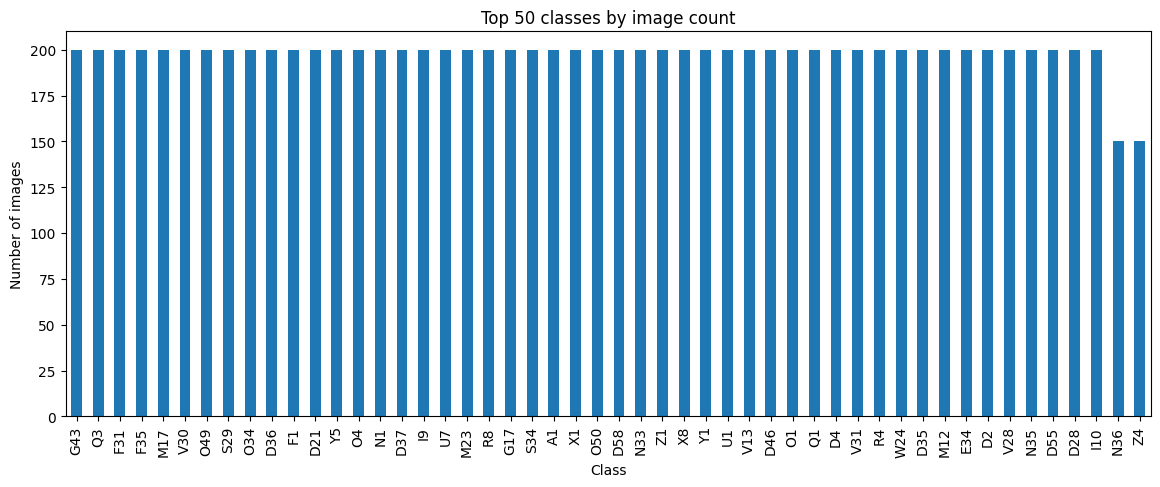

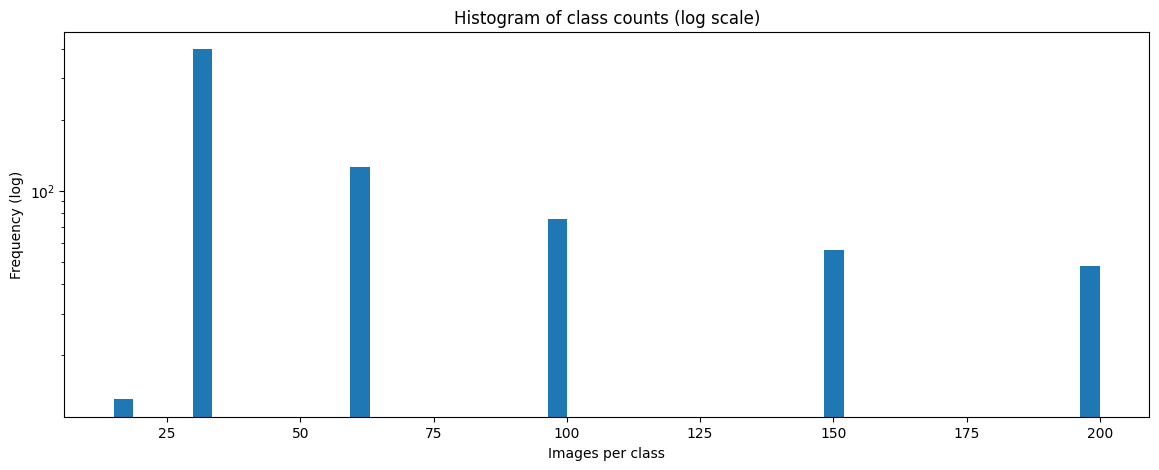

In [29]:
train_class_counts = (
    train_df["label"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Total classes:", len(train_class_counts))
print("Total images:", train_class_counts.sum())

display(train_class_counts.head(10))
display(train_class_counts.tail(10))

plt.figure(figsize=(14,5))
train_class_counts.head(50).plot(kind="bar")
plt.title("Top 50 classes by image count")
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(14,5))
train_class_counts.plot(kind="hist", bins=50)
plt.yscale("log")
plt.title("Histogram of class counts (log scale)")
plt.xlabel("Images per class")
plt.ylabel("Frequency (log)")
plt.show()

In [30]:
freq_series = train_class_counts.value_counts().sort_index()

freq = pd.DataFrame({
    "images_per_class": freq_series.index,
    "num_classes": freq_series.values
})

display(freq)

,images_per_class,num_classes
0,15,13
1,30,399
2,60,126
3,100,76
4,150,56
5,200,48


In [31]:
max_count = train_class_counts.max()
min_count = train_class_counts.min()

print("Max:", max_count)
print("Min:", min_count)
print("Ratio:", max_count / min_count)

Max: 200
Min: 15
Ratio: 13.333333333333334


In [32]:
train_label_indices = train_df["label_idx"].values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_label_indices
)

weights = np.sqrt(weights)

class_weights = {i: float(w) for i, w in enumerate(weights)}

print("Min class weight:", min(class_weights.values()))
print("Max class weight:", max(class_weights.values()))
print("Example weights:", list(class_weights.items())[:10])

Min class weight: 0.5618128734154959
Max class weight: 2.051450559109744
Example weights: [(0, 0.5618128734154959), (1, 1.450594601615434), (2, 1.450594601615434), (3, 1.450594601615434), (4, 1.450594601615434), (5, 1.025725279554872), (6, 1.025725279554872), (7, 1.450594601615434), (8, 1.025725279554872), (9, 1.450594601615434)]


In [33]:
online_aug = keras.Sequential([
    layers.RandomRotation(0.025),
    layers.RandomZoom(0.04),
    layers.RandomTranslation(0.025, 0.025),
    layers.RandomContrast(0.05),
    layers.RandomBrightness(0.05),
    layers.GaussianNoise(0.02),
], name="online_augmentation")

In [34]:
preprocess_input = tf.keras.applications.efficientnet_v2.preprocess_input

base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = online_aug(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dropout(0.35)(x)
x = layers.Dense(512,activation="gelu",kernel_regularizer=keras.regularizers.l2(WEIGHT_DECAY))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

outputs = layers.Dense(NUM_CLASSES,activation="softmax",dtype="float32")(x)
model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ online_augmentation             │ (None, 256, 256, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 8, 8, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 718)            │       368,334 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,362,734 (81.49 MB)

 Trainable params: 1,027,790 (3.92 MB)

 Non-trainable params: 20,334,944 (77.57 MB)

### Head Stage

In [35]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")
    ]
)

In [36]:
callbacks_head = [
    keras.callbacks.ModelCheckpoint(
        "best_head_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [37]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_head,
    class_weight= class_weights
)

Epoch 1/15


E0000 00:00:1777834721.268469      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1777834724.198950     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.2261 - loss: 4.2029 - top3: 0.3414 - top5: 0.3971
Epoch 1: val_loss improved from inf to 1.90065, saving model to best_head_model.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 211s 131ms/step - accuracy: 0.2262 - loss: 4.2020 - top3: 0.3415 - top5: 0.3972 - val_accuracy: 0.5957 - val_loss: 1.9007 - val_top3: 0.7561 - val_top5: 0.8068 - learning_rate: 0.0010
Epoch 2/15
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.6030 - loss: 1.4836 - top3: 0.7812 - top5: 0.8387
Epoch 2: val_loss improved from 1.90065 to 1.82255, saving model to best_head_model.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 181s 128ms/step - accuracy: 0.6030 - loss: 1.4836 - top3: 0.7812 - top5: 0.8387 - val_accuracy: 0.6195 - val_loss: 1.8226 - val_top3: 0.7833 - val_top5: 0.8377 - learning_rate: 0.0010
Epoch 3/15
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.6567 - loss: 1.2755 - top3: 0.8195 - top5: 0.8751
Epoch 3: val_loss did not improve from 1.8225

In [69]:
def plot_history(history, title="Training History"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist["accuracy"], label="train_acc")
    plt.plot(hist["val_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.show()

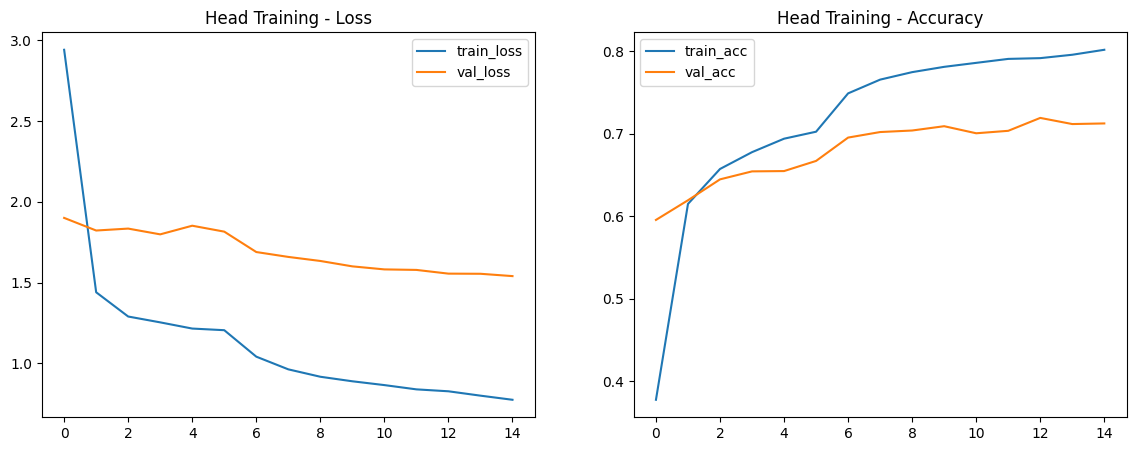

In [70]:
plot_history(history_head, title="Head Training")

In [71]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

In [41]:
"""y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)

    preds = np.argmax(probs, axis=1)
    true = np.argmax(labels.numpy(), axis=1)

    y_true.extend(true)
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)"""

'y_true = []\ny_pred = []\ny_probs = []\n\nfor images, labels in test_ds:\n    probs = model.predict(images, verbose=0)\n\n    preds = np.argmax(probs, axis=1)\n    true = np.argmax(labels.numpy(), axis=1)   \n\n    y_true.extend(true)\n    y_pred.extend(preds)\n    y_probs.extend(probs)\n\ny_true = np.array(y_true)\ny_pred = np.array(y_pred)\ny_probs = np.array(y_probs)'

In [42]:
print(y_true[:10])
print(y_pred[:10])

[614 400 400 400 400 682 381 381 381 381]
[674 400 400 400 400 682 381 381 381 381]


In [43]:
print("Head Test Accuracy:", accuracy_score(y_true, y_pred))
print("Head Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Head Macro F1:", f1_score(y_true, y_pred, average="macro"))

Head Test Accuracy: 0.7141750580945004
Head Balanced Accuracy: 0.5365124067901791
Head Macro F1: 0.48360096322314694


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [44]:
top3 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
top5 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

top3.update_state(y_true, y_probs)
top5.update_state(y_true, y_probs)

print("Top-3 Head Test Accuracy:", top3.result().numpy())
print("Top-5 Head Test Accuracy:", top5.result().numpy())

Top-3 Head Test Accuracy: 0.8427575
Top-5 Head Test Accuracy: 0.87955076


### Fine-tuning

In [45]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.85)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print("Total base layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)
print("Trainable layers:", sum([layer.trainable for layer in base_model.layers]))

Total base layers: 513
Fine-tuning from layer: 436
Trainable layers: 77


In [46]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINE_1),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")
    ]
)

In [47]:
callbacks_fine_1 = [
    keras.callbacks.ModelCheckpoint(
        "best_finetuned_stage1.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        mode="min",
        verbose=1
    )
]

In [48]:
history_fine_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_1,
    callbacks=callbacks_fine_1,
    class_weight=class_weights
)

Epoch 1/20


E0000 00:00:1777837495.461865      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7296 - loss: 1.0277 - top3: 0.8747 - top5: 0.9141
Epoch 1: val_loss improved from inf to 1.72972, saving model to best_finetuned_stage1.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 261s 163ms/step - accuracy: 0.7296 - loss: 1.0276 - top3: 0.8747 - top5: 0.9141 - val_accuracy: 0.6821 - val_loss: 1.7297 - val_top3: 0.8179 - val_top5: 0.8660
Epoch 2/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7544 - loss: 0.9242 - top3: 0.8881 - top5: 0.9279
Epoch 2: val_loss improved from 1.72972 to 1.66569, saving model to best_finetuned_stage1.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 225s 159ms/step - accuracy: 0.7544 - loss: 0.9242 - top3: 0.8881 - top5: 0.9279 - val_accuracy: 0.6906 - val_loss: 1.6657 - val_top3: 0.8287 - val_top5: 0.8730
Epoch 3/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7772 - loss: 0.8507 - top3: 0.9038 - top5: 0.9371
Epoch 3: val_loss improved from 1.66569 to 1.62308, saving model to best_finetune

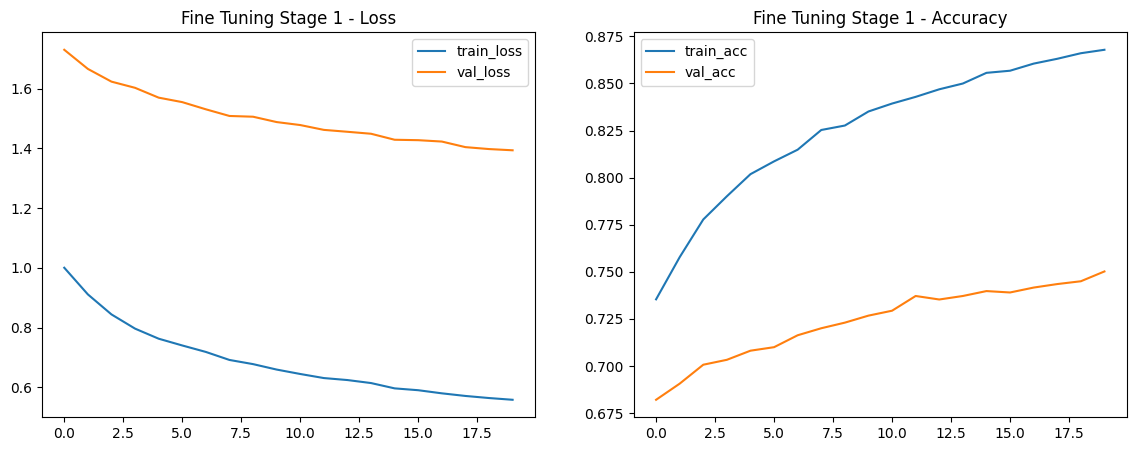

In [49]:
plot_history(history_fine_1, title="Fine Tuning Stage 1")

In [50]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

In [51]:
print("Fine_Stage1 Test Accuracy:", accuracy_score(y_true, y_pred))
print("Fine_Stage1 Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Fine_Stage1 Macro F1:", f1_score(y_true, y_pred, average="macro"))

Fine_Stage1 Test Accuracy: 0.761425251742835
Fine_Stage1 Balanced Accuracy: 0.563539052590392
Fine_Stage1 Macro F1: 0.5141537183796245


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [52]:
top3_2 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
top5_2 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

top3_2.update_state(y_true, y_probs)
top5_2.update_state(y_true, y_probs)

print("Top-3 Fine_Stage1 Test Accuracy:", top3_2.result().numpy())
print("Top-5 Fine_Stage1 Test Accuracy:", top5_2.result().numpy())

Top-3 Fine_Stage1 Test Accuracy: 0.8745159
Top-5 Fine_Stage1 Test Accuracy: 0.9004648


In [53]:
"""base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.70)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print("Fine-tuning from layer:", fine_tune_at)
print("Trainable base layers:", sum(layer.trainable for layer in base_model.layers))"""

'base_model.trainable = True\n\nfine_tune_at = int(len(base_model.layers) * 0.70)\n\nfor layer in base_model.layers[:fine_tune_at]:\n    layer.trainable = False\n\nfor layer in base_model.layers[fine_tune_at:]:\n    layer.trainable = True\n\nprint("Fine-tuning from layer:", fine_tune_at)\nprint("Trainable base layers:", sum(layer.trainable for layer in base_model.layers))'

In [54]:
"""model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_FINE_2,weight_decay=WEIGHT_DECAY),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")
    ]
)"""

'model.compile(\n    optimizer=keras.optimizers.AdamW(learning_rate=LR_FINE_2,weight_decay=WEIGHT_DECAY),\n    loss=keras.losses.SparseCategoricalCrossentropy(),\n    metrics=[\n        "accuracy",\n        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3"),\n        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")\n    ]\n)'

In [55]:
"""callbacks_fine_2 = [
    keras.callbacks.ModelCheckpoint(
        "best_finetuned_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-8,
        verbose=1
    )
]"""

'callbacks_fine_2 = [\n    keras.callbacks.ModelCheckpoint(\n        "best_finetuned_model.keras",\n        monitor="val_loss",\n        save_best_only=True,\n        mode="min",\n        verbose=1\n    ),\n    keras.callbacks.EarlyStopping(\n        monitor="val_loss",\n        patience=4,\n        restore_best_weights=True,\n        mode="min",\n        verbose=1\n    ),\n    keras.callbacks.ReduceLROnPlateau(\n        monitor="val_loss",\n        factor=0.3,\n        patience=2,\n        min_lr=1e-8,\n        verbose=1\n    )\n]'

In [56]:
"""history_fine_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_2,
    callbacks=callbacks_fine_2,
    class_weight=class_weights
)"""

'history_fine_2 = model.fit(\n    train_ds,\n    validation_data=val_ds,\n    epochs=EPOCHS_FINE_2,\n    callbacks=callbacks_fine_2,\n    class_weight=class_weights\n)'

In [57]:
"""plot_history(history_fine_2, title="Fine Tuning Stage 2")"""

'plot_history(history_fine_2, title="Fine Tuning Stage 2")'

In [58]:
"""y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)"""

'y_true = []\ny_pred = []\ny_probs = []\n\nfor images, labels in test_ds:\n    probs = model.predict(images, verbose=0)\n    preds = np.argmax(probs, axis=1)\n\n    y_true.extend(labels.numpy())\n    y_pred.extend(preds)\n    y_probs.extend(probs)\n\ny_true = np.array(y_true)\ny_pred = np.array(y_pred)\ny_probs = np.array(y_probs)'

In [59]:
"""print("Fine_Stage2 Test Accuracy:", accuracy_score(y_true, y_pred))
print("Fine_Stage2 Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Fine_Stage2 Macro F1:", f1_score(y_true, y_pred, average="macro"))"""

'print("Fine_Stage2 Test Accuracy:", accuracy_score(y_true, y_pred))\nprint("Fine_Stage2 Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))\nprint("Fine_Stage2 Macro F1:", f1_score(y_true, y_pred, average="macro"))'

In [60]:
"""top3_3 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
top5_3 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

top3_3.update_state(y_true, y_probs)
top5_3.update_state(y_true, y_probs)

print("Top-3 Fine_Stage2 Test Accuracy:", top3_3.result().numpy())
print("Top-5 Fine_Stage2 Test Accuracy:", top5_3.result().numpy())"""

'top3_3 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)\ntop5_3 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)\n\ntop3_3.update_state(y_true, y_probs)\ntop5_3.update_state(y_true, y_probs)\n\nprint("Top-3 Fine_Stage2 Test Accuracy:", top3_3.result().numpy())\nprint("Top-5 Fine_Stage2 Test Accuracy:", top5_3.result().numpy())'

### Testing

In [61]:
model = keras.models.load_model("best_finetuned_stage1.keras")

In [62]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

In [63]:
print("Final Test Accuracy:", accuracy_score(y_true, y_pred))
print("Final Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Final Macro F1:", f1_score(y_true, y_pred, average="macro"))

Final Test Accuracy: 0.761425251742835
Final Balanced Accuracy: 0.563539052590392
Final Macro F1: 0.5141537183796245


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [64]:
top3_final = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
top5_final = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

top3_final.update_state(y_true, y_probs)
top5_final.update_state(y_true, y_probs)

print("Final Top-3 Accuracy:", top3_final.result().numpy())
print("Final Top-5 Accuracy:", top5_final.result().numpy())

Final Top-3 Accuracy: 0.8745159
Final Top-5 Accuracy: 0.9004648


In [65]:
test_present_classes = np.unique(y_true)

mask = np.isin(y_true, test_present_classes)

print("Classes in train:", NUM_CLASSES)
print("Classes in test:", len(test_present_classes))

print("Test-present Accuracy:", accuracy_score(y_true[mask], y_pred[mask]))
print("Test-present Balanced Accuracy:", balanced_accuracy_score(y_true[mask], y_pred[mask]))
print("Test-present Macro F1:", f1_score(y_true[mask], y_pred[mask], average="macro"))

Classes in train: 718
Classes in test: 562
Test-present Accuracy: 0.761425251742835
Test-present Balanced Accuracy: 0.563539052590392
Test-present Macro F1: 0.5141537183796245


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [66]:
report = classification_report(
    y_true,
    y_pred,
    labels=np.unique(y_true),
    target_names=[class_names[i] for i in np.unique(y_true)],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
class_report_df = report_df.iloc[:-3].copy()

display(class_report_df.sort_values("f1-score").head(30))

,precision,recall,f1-score,support
D14,0.0,0.0,0.0,1.0
D156,0.0,0.0,0.0,1.0
D16,0.0,0.0,0.0,1.0
D18,0.0,0.0,0.0,1.0
X2,0.0,0.0,0.0,1.0
B3,0.0,0.0,0.0,1.0
C10,0.0,0.0,0.0,1.0
D56,0.0,0.0,0.0,2.0
A21,0.0,0.0,0.0,1.0
A26,0.0,0.0,0.0,1.0


In [67]:
model.save("hieroglyph_efficientnetv2s_final.keras")

label_map = pd.DataFrame({
    "class_index": list(range(len(class_names))),
    "gardiner_code": class_names
})

label_map.to_csv("label_map.csv", index=False)

print("Saved model and label map.")

Saved model and label map.


In [68]:
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

pd.DataFrame({
    "gardiner_code": list(class_to_idx.keys()),
    "class_index": list(class_to_idx.values())
}).to_csv("class_to_idx.csv", index=False)